## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Cody Chhea 

**Date:** 10/2/2026

1. What is the difference between regression and classification?
- Regression predicts a continuous numerical value. On the other hand, classification predicts a category or class label, typically predicting if something is right or wrong. A regressor predicts the average k neighbor's values, while a classifier predicts the most common class among k neighbors.  

2. What is a confusion table? What does it help us understand about a model's performance?
- A confusion table is a table used to evaluate how well a classifier model performs, comparing its prediction to the actual true values. It helps us understand how accurate a model's performance is to the test model. 

3. What does the SSE quantify about a particular model?
- SSE is the sum of squared errors. It measures how far the model's prediction is from the actual values. Because of this, a lower SSE means that the model is a better fit. Getting the SSE on the test data measures how well the model predicts new data. 

4. What are overfitting and underfitting? 

- Overfitting is when the k values are too small, making a model too heavily affected by a small number of neighbors, encouraging noise in the training data to affect the classifier greatly. Underfitting is when a model is too simple to capture a real pattern. It averages over so many distant neighbors that it makes everything toward the overall average or most common data, giving nearly the same prediction for every observation. A good model finds a balance between the two extremes.  

5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?

- By splitting the data into training and testing sets, and choosing k by evaluating accuracy or SSE on the test set, it allows us to accurately test the model on data it has never seen. It allows us to get an accurate accuracy/SSE value that actually estimates how well the model will perform on new observations. If we didn't split the data and tested the model on data it was built on, we'll get inflated/optimistic results that are misleading of the model's true accuracy.

6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.
- Reporting a single class label is simple andeasy to evaluate, but it hides the model's confidence by treating a 51% guess the same as a 100% certainty and ignores the varying costs of different errors. In contrast, providing a probability distribution explicitly conveys this uncertainty. However, distributions are harder to interpret and can cause inaccurate interpretations.

(338, 4)
voltage      0
height       0
soil         0
mine_type    0
dtype: int64
mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64


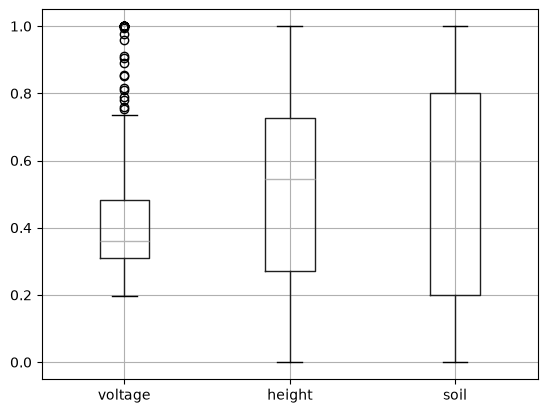

In [21]:
# Your Phase 1 solution to the problem goes here.
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#ask how much eda is needed, shoudl i plot too? 
df = pd.read_csv('land_mines.csv')
print(df.shape) # dimensions are 338 x 4, 338 observations
print(df.isna().sum()) #there's no missing data in any of the columns 
df[['voltage', 'height', 'soil']].describe().round(3)
df.groupby("mine_type")[["voltage", "height", "soil"]].mean().round(3)
print(df["mine_type"].value_counts().sort_index())


box = df.boxplot(column=['voltage', 'height', 'soil'])
plt.show()



In [90]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

eval_X_raw = df[["voltage", "height", "soil"]]
eval_y = df["mine_type"]
(
    eval_X_train_raw,
    eval_X_valid_raw,
    eval_y_train,
    eval_y_valid,
) = train_test_split(
    eval_X_raw, eval_y, test_size=0.50, random_state=65
)

eval_scaler = MinMaxScaler()
eval_X_train_scaled = eval_scaler.fit_transform(eval_X_train_raw)
eval_X_valid_scaled = eval_scaler.transform(eval_X_valid_raw)


In [91]:
from sklearn.neighbors import KNeighborsClassifier
from math import sqrt

classification_model = KNeighborsClassifier(n_neighbors=3).fit(
    eval_X_train_scaled, eval_y_train
) # mine_X_train_scaled are the examples we want the model to learn from, while eval_y_train are the corresponding results 

print("Validation accuracy (k = 3):",
      round(classification_model.score(eval_X_valid_scaled, eval_y_valid), 3))

k_values = range(1,51)
validation_accuracies = []
for k in k_values: 
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(eval_X_train_scaled, eval_y_train)
    validation_accuracies.append(knn_k.score(eval_X_valid_scaled, eval_y_valid))

k_position = k_values[int(np.argmax(validation_accuracies))]
print(k_position) #most optimal k, found that most optimal is k = 2

k = sqrt(len(eval_X_train_scaled)) #rule of thumb k sqrt(n)
print(k)

accuracy_table = pd.DataFrame({
    "k": list(k_values),
    "validation accuracy": validation_accuracies,
})
accuracy_table.round(3)

# Final k-NN classifier with the chosen k 
final_k = 11
knn_final = KNeighborsClassifier(n_neighbors=final_k).fit(
    eval_X_train_scaled, eval_y_train
)
print(f"Validation accuracy (k = {final_k}):",
      round(knn_final.score(eval_X_valid_scaled, eval_y_valid), 3))


Validation accuracy (k = 3): 0.402
2
13.0
Validation accuracy (k = 11): 0.444


I think the most optimal k in my opinion is k=11. Although the k with the highest validation accuracy is k=2, the value is too small which risks overfitting and bias. Because of that, I started looking at k values that are closer to the sqrt(n) rule of thumb, which is 13. 11 has the highest validation accuracy and is relatively similar to 13 that it doesn't risk any overfitting or underfitting, which is why I believe that this is the best k value.  

In [94]:

eval_y_pred = knn_final.predict(eval_X_valid_scaled)

pd.crosstab(eval_y_valid, eval_y_pred,
            rownames=["Actual"], colnames=["Predicted"], margins=True)


Predicted,1,2,3,4,5,All
Actual,,,,,,
1,26,0,3,2,3,34
2,0,30,6,0,2,38
3,3,2,10,2,13,30
4,14,0,13,4,7,38
5,11,0,11,2,5,29
All,54,32,43,10,30,169


In [96]:
correct = 26+30+10+4+5 
accuracy = correct / len(eval_y_valid)
print(accuracy)


0.4437869822485207


The model correctly classifies 75 of the 169 mines giving it an accuracy of 44.4% The model seems to be able to classify type 2 mines the best as it was able to classify 30/32 type 2 mines correctly. It did fairly well in classifying type 1 mines as well, being able to correctly identify 26/54 of type 1 mines. On the other hand, it didn't do very well in classifying Type 3, 4, and 5 landmines (the model classified other types more frequently than the correct type mine type). 


Given that there are accurate predictions for a given type of mine (1 and 2), but the model remains fairy inaccurate, I would suggest that people use this model to be used alongside another method of determining types of mines on the ground. The model is not accurate enough to be used as a decision maker as its inaccuracy can cause a life, however, it can definitely still be used as a support tool. But honestly, I suggest that this model should be built on more/better data in order to refine the classifier to be more accurate before usage on the field. 

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [a3dc0deedaca1f1e068bbba1cc1784719b75d73a]
- **AI tool and model used:** [Claude Opus 5.5]

### *Prompts used

1. Put notebook and rubric into claude. Grade my assignment based off the rubric and tell me any improvements I can make. 
2. Put rubric of Q2, grade Q2 as well. 
3. Should I change my boxplot per suggestions in 2 (prompt 2). 
4. Did I summarize labels and features in 2.2? 

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Here's the grade and the feedback.

Q1 grade (rubric: 45 points)
Part	Good attempt	Accuracy	Why points are lost
1. Regression vs classification	2.5/2.5	4/5	"typically predicting if something is right or wrong" is wrong. Classification predicts a category, not right/wrong. The average-vs-vote point is specific to k-NN, so label it that way.
2. Confusion table	2.5/2.5	3/5	"how accurate a model's performance is to the test model" is vague. It misses the key point: the table shows which classes are confused with which, not just overall accuracy.
3. SSE	2.5/2.5	4.5/5	Solid. Could add the formula and that squaring penalizes large errors more.
4. Overfitting/underfitting	2.5/2.5	3.5/5	Overfitting is defined only as "k too small." It's a general idea: the model fits noise, does well on training data, and does poorly on new data. Small k is just one example.
5. Train/test split	2.5/2.5	4/5	Good. Add that choosing k on the test set picks the k that generalizes best, balancing over- and underfitting.
6. Label vs probability	2.5/2.5	3.5/5	It doesn't name the main strength of probabilities: you can set cautious thresholds based on the cost of errors. "Can cause inaccurate interpretations" is vague, and "andeasy" is a typo.
Total	15/15	22.5/30	≈ 37.5 / 45
Q2 feedback

The Q2 rubric wasn't in your screenshots, so this is feedback rather than a grade.

Bugs in your code

Two EDA outputs never appear. describe() and groupby(...).mean() aren't the last line of the cell, so Jupyter doesn't display them. Wrap each in display(...).
The accuracy table never appears either, for the same reason. Use display(accuracy_table.round(3)).
The file path may fail. You load 'land_mines.csv', but in the repo the file is in data/land_mines.csv.
The correct count is hard-coded as 26+30+10+4+5. Compute it with (eval_y_valid.to_numpy() == eval_y_pred).sum().
Small cleanups:
A comment says mine_X_train_scaled, but the code uses eval_X_train_scaled.
k = sqrt(...) reuses the loop variable k.
A comment says the optimal k is 2, but you chose 11.

Errors in your written answers

Q2.4 mixes up precision and recall.
"30/32 type 2 mines" should be 30 of 38 actual type-2 mines. 30/32 is the share of type-2 predictions that were right.
"26/54 of type 1" should be 26 of 34.
Q2.4 is thin on where the model fails. Add the specifics:
type 4 is caught only 4 of 38 times;
types 3 and 5 are mostly confused with each other;
28 real mines were predicted as "no mine."
Q2.3 reasoning:
Small k means overfitting with low bias and high variance, so remove "bias."
"Doesn't risk any overfitting or underfitting" is too absolute.
Add the numbers: k = 2 gives 0.450 and k = 11 gives 0.444, only one mine apart.
Q2.5 doesn't answer the specific question. The prompt is about getting many predictions right while still making many mistakes. Use your own table: the model predicts "no mine" 54 times, and 28 of those are real mines. Then give concrete advice:
never use a "no mine" prediction to clear ground;
trust type-2 predictions most;
group types 3–5 together.
EDA has no written summary. Add two or three sentences: the classes are balanced, there's no missing data, voltage separates type 2, and height and soil barely differ between types.
Typos: "fairy inaccurate" should be "fairly inaccurate," and "can cause a life" should be "can cost a life."
Phase 2 checklist
✅ Commit SHA and AI tool are filled in.
⬜ Prompts: add your follow-up prompts.
⬜ AI-proposed changes: you can paste the numbered list below verbatim.
⬜ Evaluation table: accept, modify or reject each change, with your reason and how you checked it (for example, "re-ran the cell and confirmed 30/38").
⬜ Full Phase 2 solution: a revised copy, with Phase 1 left untouched.
⬜ Reflection: 150–300 words in your own words. The rubric requires this to be written without AI, so I haven't drafted it.

Concise list to paste under "AI-proposed changes":

Q1.1: Remove "right or wrong"; classification predicts a category, and label the average/vote explanation as specific to k-NN.
Q1.2: Explain that a confusion table shows which classes are confused with each other, not only overall accuracy.
Q1.4: Define overfitting generally (fits noise; good on training, poor on new data), with small k as an example.
Q1.6: Add that probabilities allow cost-based thresholds, and that k-NN probabilities are coarse vote shares.
Q2.1: Wrap describe() and groupby() in display() and add a written EDA summary.
Q2.3: Display the accuracy table, fix the comments and the reused k variable, and correct "bias" and "no risk" in the k = 11 reasoning.
Q2.4: Compute correct predictions in code; fix 30/32 → 30/38 and 26/54 → 26/34; add type 3/4/5 errors and the 28 mines predicted as "no mine."
Q2.5: Answer the specific question using the "no mine" precision example and give concrete usage rules.
Fix the file path to data/land_mines.csv and the typos.



2. 

This grades your Phase 1 Q2 (the notebook you uploaded) against this rubric. It's my estimate; your grader may weigh things differently.

Criterion	Score	Why
2.1 Load data & EDA (9)	6 / 9	You load the data and check its shape, missing values and class counts. But describe() and groupby().mean() never appear in the output, because they aren't the last line of the cell. The boxplot shows all three features together rather than by mine type, so it can't show that voltage separates the types.
2.2 Summarize labels & features (3)	1 / 3	There's no written summary, only code comments. The rubric wants you to state what you found: the classes are balanced, there's no missing data, voltage separates type 2, and height and soil barely differ.
2.3 50/50 split (3)	3 / 3	Correct.
2.4 Build k-NN classifier (10)	9 / 10	Correct model, k search and final model. Small issues: the accuracy table isn't displayed, a comment says mine_X, and k = sqrt(...) reuses the loop variable.
2.5 Explain k selection (5)	3.5 / 5	The reasoning is good, but: "overfitting and bias" is backwards (small k means low bias); "doesn't risk any overfitting" is too absolute; there are no numbers (0.450 vs 0.444); and the code comment says the optimal k is 2.
2.6 Confusion table (5)	5 / 5	Correct table for the chosen model. (Hard-coding 26+30+... is a minor style issue.)
2.7 Accuracy analysis (5)	3 / 5	The 44.4% overall is right, but "30/32 type 2" should be 30 of 38, and "26/54 of type 1" should be 26 of 34; you divided by the column total instead of the row total. Types 3–5 are described only vaguely.
2.8 Practical advice (5)	2.5 / 5	Sensible but generic, and it doesn't address what the prompt asks: many correct predictions for a type, yet many mistakes. It should use your own table: 54 "no mine" predictions, 28 of them real mines. Typos: "fairy" should be "fairly," and "cause a life" should be "cost a life."
Total	≈ 33 / 45	

The revised Phase 2 cells I gave you earlier fix each of these:

2.1: display() added and a by-type boxplot.
2.2: a written EDA summary.
2.4: comments and variable names cleaned up, and the table displayed.
2.5: the k explanation reworded, with the numbers added.
2.7: recall and precision fixed, with specifics for types 3–5.
2.8: advice built on the "no mine" example.

With those in, Q2 should land around 43–45 / 45.


3.


Yes. Your current boxplot shows each feature's overall spread, with all mine types mixed together. That can't answer the question that matters for classification: do the features look different for different mine types? Splitting by mine type shows it right away:

Voltage: type 2's box sits much higher than the others, so voltage is what separates anti-tank mines.
Height and soil: the boxes look about the same for every type, so these features don't help much.

That's the evidence behind your EDA summary and your later explanation of why types 1, 3, 4 and 5 get confused. It also fixes the point you lost on 2.1.

4. 

For rubric item 2.2 (summarize labels and features, 3 points), you need a written summary after your EDA code, and the EDA tables have to actually display.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | The AI went through my written answers and listed any typos, explanations that were vague, and incorrect written answers. Most of the things listed were valid and definitely needs to be reviewed before turning in. For example, I read and interpreted the numbers of the confusion table incorrectly so I need to go back and fix the numbers I mentioned. Although my interpretation remains the same, I stated incorrect numbers in my explanation. Some of my explanations in part 1 were also vague and needs rewording/slight altering to be more accurate. For example, my explanation of underfitting and overfitting/other concepts were too simplified and inaccurate to what the actual definitions are.|
| 2 | Accept | Graded my Q2. Revealed some errors in my code where I don't display some of my tables. Also pointed out that my boxplot for the EDA section was incorrect, which I changed|
| 3 | Accept | Explained to me that by splitting the boxplots up by mine types instead of having all types mixed together in the boxplot, it allows me to see how they're different from each other in features, which can help explain why the model confuses certain types. I agreed with this statement and did see how the boxplots were visually different and more accurate to our conclusion | 
| 4| Accept | Told me that I was missing a summary for 2.2 as described in the rubric on Canvas. | 


### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

# Your Phase 2 solution to the problem goes here. (accepted revisions from Phase 1 were incorporated here)
**Q1.**

1. **What is the difference between regression and classification?**
- Regression predicts a continuous numerical value (e.g., sales or price), where the size of the error matters. Classification predicts a category or class label (e.g., mine type), where each prediction is either correct or incorrect. With k-NN specifically, a regressor predicts the average of the k nearest neighbors' values, while a classifier predicts the most common class among the k nearest neighbors (a majority vote). Regression is usually evaluated with SSE, and classification with accuracy and a confusion table.

2. **What is a confusion table? What does it help us understand about a model's performance?**
- A confusion table is a table used to evaluate how well a classifier model performs, comparing its prediction to the actual true values.  The diagonal counts correct predictions, and each off-diagonal cell counts a specific type of mistake. Beyond overall accuracy, it shows which classes the model predicts well, which classes it confuses with each other, and whether errors are concentrated in particular directions. This matters because different errors can have very different effects. Prediciting an area that actually has mines as 'no mines' would be dangerous. 

3. **What does the SSE quantify about a particular model?**
- SSE is the sum of squared errors. It measures how far the model's prediction is from the actual values. Because of this, a lower SSE means that the model is a better fit. Getting the SSE on the test data measures how well the model predicts new data. 


4. **What are overfitting and underfitting?**
- Overfitting is when a model is too flexible and learns the noise in the training data instead of just the real pattern. It does really well on the training data but poorly on new data. In k-NN, this happens when k is too small, because each prediction depends on only a few neighbors. For example, with k = 1 the model gets every training point right, since each point is its own nearest neighbor, but it does much worse on the test data. Underfitting is when a model is too simple to capture the real pattern, so it does poorly on both the training data and new data. In k-NN, this happens when k is too large, because the model averages over so many distant neighbors that its predictions get pulled toward the overall average or most common class, giving nearly the same prediction for every observation. A good model finds a balance between the two extremes.

5. **Why does splitting the data into training and testing sets, and choosing k by evaluating accuracy or SSE on the test set, improve model performance?**
 - By splitting the data into training and testing sets, and choosing k by evaluating accuracy or SSE on the test set, it allows us to accurately test the model on data it has never seen. It allows us to get an accurate accuracy/SSE value that actually estimates how well the model will perform on new observations. If we didn't split the data and tested the model on data it was built on, we'll get inflated/optimistic results that are misleading of the model's true accuracy.

6. **With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.**
- Reporting a single class label is simple, clear, and easy to evaluate with accuracy and a confusion table. However, it hides the model's confidence: a 51% vote and a 100% vote produce the same label, and it ignores the different costs of different errors. A probability distribution conveys this uncertainty and shows which classes the model is torn between. However, probabilities are harder to interpret and communicate, they still need a decision rule to become an action, and they may be poorly calibrated. 



(338, 4)
voltage      0
height       0
soil         0
mine_type    0
dtype: int64


,voltage,height,soil
count,338.000,338.000,338.000
mean,0.431,0.509,0.504
std,0.196,0.306,0.344
min,0.198,0.000,0.000
25%,0.310,0.273,0.200
50%,0.360,0.545,0.600
75%,0.483,0.727,0.800
max,1.000,1.000,1.000


,voltage,height,soil
mine_type,,,
1,0.296,0.496,0.493
2,0.721,0.487,0.509
3,0.402,0.528,0.497
4,0.345,0.507,0.503
5,0.380,0.530,0.517


mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64


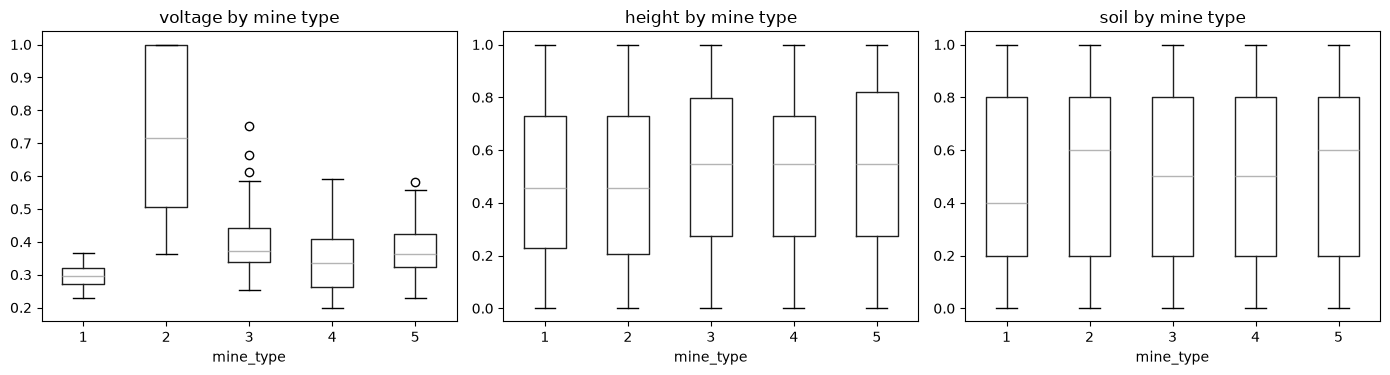

In [105]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('land_mines.csv')
print(df.shape) # dimensions are 338 x 4, 338 observations
print(df.isna().sum()) #there's no missing data in any of the columns 
display(df[['voltage', 'height', 'soil']].describe().round(3))
display(df.groupby("mine_type")[["voltage", "height", "soil"]].mean().round(3))
print(df["mine_type"].value_counts().sort_index())


fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ["voltage", "height", "soil"]):
    df.boxplot(column=col, by="mine_type", ax=ax, grid=False)
    ax.set_title(f"{col} by mine type")
    ax.set_xlabel("mine_type")
plt.suptitle("")
plt.tight_layout()
plt.show()


The data has 338 observations with no missing values. The target label and mine_type variable seem pretty balanced, with 65 to 71 observations for each of the 5 mine types.  All three features are already between 0 and 1. Soil only takes 6 different values and height takes 12. Voltage seems to be the most useful feature, since type 2 mines have a much higher average voltage (0.721) than the other types (0.296 to 0.402), which you can also see in the boxplot. Height and soil have almost the same average for every type (around 0.49 to 0.53), so they don't help much in telling the mine types apart. Because of this, I expect the model to do well on type 2 mines but have a harder time separating types 1, 3, 4, and 5.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

eval_X_raw = df[["voltage", "height", "soil"]]
eval_y = df["mine_type"]
(
    eval_X_train_raw,
    eval_X_valid_raw,
    eval_y_train,
    eval_y_valid,
) = train_test_split(
    eval_X_raw, eval_y, test_size=0.50, random_state=65
)

eval_scaler = MinMaxScaler()
eval_X_train_scaled = eval_scaler.fit_transform(eval_X_train_raw)
eval_X_valid_scaled = eval_scaler.transform(eval_X_valid_raw)



In [106]:
from sklearn.neighbors import KNeighborsClassifier
from math import sqrt

classification_model = KNeighborsClassifier(n_neighbors=3).fit(
    eval_X_train_scaled, eval_y_train
) # mine_X_train_scaled are the examples we want the model to learn from, while eval_y_train are the corresponding results 

print("Validation accuracy (k = 3):",
      round(classification_model.score(eval_X_valid_scaled, eval_y_valid), 3))

k_values = range(1,51)
validation_accuracies = []
for k in k_values: 
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(eval_X_train_scaled, eval_y_train)
    validation_accuracies.append(knn_k.score(eval_X_valid_scaled, eval_y_valid))

k_position = k_values[int(np.argmax(validation_accuracies))]
print(k_position) #most optimal k, found that most optimal is k = 2

k = sqrt(len(eval_X_train_scaled)) #rule of thumb k sqrt(n)
print(k)

accuracy_table = pd.DataFrame({
    "k": list(k_values),
    "validation accuracy": validation_accuracies,
})
display(accuracy_table.round(3))

# Final k-NN classifier with the chosen k 
final_k = 11
knn_final = KNeighborsClassifier(n_neighbors=final_k).fit(
    eval_X_train_scaled, eval_y_train
)
print(f"Validation accuracy (k = {final_k}):",
      round(knn_final.score(eval_X_valid_scaled, eval_y_valid), 3))


Validation accuracy (k = 3): 0.402
2
13.0


,k,validation accuracy
0,1,0.414
1,2,0.450
2,3,0.402
3,4,0.391
4,5,0.379
5,6,0.349
6,7,0.379
7,8,0.385
8,9,0.414
9,10,0.426


Validation accuracy (k = 11): 0.444


To pick k, I tested every k from 1 to 50 and compared their validation accuracy. I think the optimal k in my opinion is k=11. Although the k with the highest validation accuracy is k=2 (0.450), the value is too small, which makes the model sensitive to noise and risks overfitting. Because of that, I started looking at k values that are closer to the sqrt(n) rule of thumb, which is 13. Out of all the k values of 3 or higher, 11 has the highest validation accuracy (0.444), which is only about one mine worse than k=2. It is also close to 13, so it is less likely to overfit, which is why I believe that this is the best k value.

In [103]:

eval_y_pred = knn_final.predict(eval_X_valid_scaled)

pd.crosstab(eval_y_valid, eval_y_pred,
            rownames=["Actual"], colnames=["Predicted"], margins=True)


Predicted,1,2,3,4,5,All
Actual,,,,,,
1,26,0,3,2,3,34
2,0,30,6,0,2,38
3,3,2,10,2,13,30
4,14,0,13,4,7,38
5,11,0,11,2,5,29
All,54,32,43,10,30,169


In [ ]:
correct = 26+30+10+4+5 
accuracy = correct / len(eval_y_valid)
print(accuracy)


The model correctly classifies 75 of the 169 mines, giving it an accuracy of 44.4%. The model seems to be able to classify type 2 mines the best, as it was able to correctly classify 30/38 type 2 mines, and when it predicts type 2 it is right 30/32 times. It did fairly well in classifying type 1 mines as well, being able to correctly identify 26/34 of type 1 mines. However, it predicted type 1 a total of 54 times, and 28 of those were actually real mines (3 of type 3, 14 of type 4, and 11 of type 5). On the other hand, it didn't do very well in classifying type 3, 4, and 5 landmines. Type 4 was the worst, with only 4/38 classified correctly, and most of them were predicted as type 1 or type 3. Types 3 and 5 were often mixed up with each other, with 13 type 3 mines predicted as type 5 and 11 type 5 mines predicted as type 3.

Given that there are a lot of accurate predictions for some types of mines (1 and 2), the model still makes a lot of mistakes. For example, the model correctly identifies 26/34 type 1 observations, but it predicted type 1 a total of 54 times, and  28 of those were actually real. Because of this, I would suggest that people use this model alongside another method of determining types of mines on the ground. The model is not accurate enough to be used as a decision maker, but it can definitely still be used as a support tool.  The model is most reliable for type 2 mines, since it is right 30/32 times when it predicts type 2, so that prediction can help teams prepare. Since the model mixes up types 3, 4, and 5, people can still use that info to avoid those areas as mines are still dangerous no matter the type; however, identifying the type of mine will be inaccurate with this model. I suggest that this model should be built on more/better data in order to refine the classifier to be more accurate before usage on the field.

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

The usage of AI helped me catch any typos I made, any incorrect numbers I listed (my ratios for predictions that were correct were off), and helped me improve my written responses to be more accurate and concise. For every suggestion that the AI made, I went back to make sure that the answer suggestions matched what the data reveals. I also cross referenced online google sources to see if the AI explained these machine learning concepts accurately or not (underfitting, overfitting, how k works, etc). Some limitations AI has was that it always tries to change my code even if it was right. Yes, the code could be written cleaner. However, the code gets the job done and is concise with what the question expects. AI's explanation of concepts are also too lengthy and wordy at times, which over complicates simple answers. However, overall, the AI did alot better in this assignment than previous. I was a bit confused as to where to include my revised solutions for part 1 after using AI to check. I included my revision in Phase 2 (I'm not sure if that is right). 